In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── Config ──────────────────────────────────────────────────────────────
DATASET_DIR  = "/kaggle/input/datasets/zlatan599/garbage-dataset-classification/Garbage_Dataset_Classification/images"
OUTPUT_DIR   = "/kaggle/working"
CLASSES      = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
NUM_CLASSES  = len(CLASSES)

IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.2
SEED         = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# ── Find the correct dataset path ───────────────────────────────────────
import os

def find_image_dirs(base="/kaggle/input", depth=0, max_depth=5):
    if depth > max_depth:
        return
    try:
        entries = os.listdir(base)
    except PermissionError:
        return
    for entry in sorted(entries):
        full = os.path.join(base, entry)
        if os.path.isdir(full):
            # Check if it contains class subfolders with images
            subdirs = [s for s in os.listdir(full) if os.path.isdir(os.path.join(full, s))]
            if any(s in subdirs for s in ["cardboard", "glass", "metal", "paper", "plastic", "trash"]):
                print(f"✅ FOUND IMAGES DIR: {full}")
                print(f"   Subfolders: {subdirs}")
            else:
                find_image_dirs(full, depth + 1, max_depth)

find_image_dirs()

✅ FOUND IMAGES DIR: /kaggle/input/datasets/zlatan599/garbage-dataset-classification/Garbage_Dataset_Classification/images
   Subfolders: ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']


In [3]:
# ── Transforms ──────────────────────────────────────────────────────────
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Dataset & Split ─────────────────────────────────────────────────────
full_dataset = datasets.ImageFolder(DATASET_DIR)
total        = len(full_dataset)
val_size     = int(total * VAL_SPLIT)
train_size   = total - val_size

train_subset, val_subset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply separate transforms via wrapper
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):  return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

train_ds = TransformSubset(train_subset, train_tfms)
val_ds   = TransformSubset(val_subset,   val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Classes: {full_dataset.classes}")

Train: 11121 | Val: 2780
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [4]:
def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    """EfficientNet-B0 with a fresh classification head."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model

model = build_model(NUM_CLASSES, freeze_backbone=True)
model = model.to(DEVICE)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s]


Trainable parameters: 329,478


In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if training:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


# ── Phase 1: Train head only (5 epochs) ─────────────────────────────────
print("=" * 55)
print("Phase 1 — Training classifier head (backbone frozen)")
print("=" * 55)
PHASE1_EPOCHS = 5

for epoch in range(PHASE1_EPOCHS):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history["train_loss"].append(tr_loss);  history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss);    history["val_acc"].append(vl_acc)

    print(f"Ep {epoch+1:>2}/{PHASE1_EPOCHS} | "
          f"Train {tr_loss:.4f}/{tr_acc:.3f} | Val {vl_loss:.4f}/{vl_acc:.3f}")


# ── Phase 2: Unfreeze & fine-tune all layers ─────────────────────────────
print("\n" + "=" * 55)
print("Phase 2 — Fine-tuning full network (lower LR)")
print("=" * 55)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR * 0.1, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - PHASE1_EPOCHS, eta_min=1e-7)
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS - PHASE1_EPOCHS):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history["train_loss"].append(tr_loss);  history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss);    history["val_acc"].append(vl_acc)

    ep_num = PHASE1_EPOCHS + epoch + 1
    star   = " ★" if vl_acc > best_val_acc else ""
    print(f"Ep {ep_num:>2}/{NUM_EPOCHS} | "
          f"Train {tr_loss:.4f}/{tr_acc:.3f} | Val {vl_loss:.4f}/{vl_acc:.3f}{star}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/best_model.pth")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Phase 1 — Training classifier head (backbone frozen)
Ep  1/5 | Train 1.0907/0.690 | Val 0.8284/0.823
Ep  2/5 | Train 0.9773/0.742 | Val 0.7899/0.843
Ep  3/5 | Train 0.9246/0.773 | Val 0.7538/0.858
Ep  4/5 | Train 0.8988/0.787 | Val 0.7366/0.869
Ep  5/5 | Train 0.8708/0.801 | Val 0.7239/0.878

Phase 2 — Fine-tuning full network (lower LR)
Ep  6/20 | Train 0.7854/0.847 | Val 0.6413/0.921 ★
Ep  7/20 | Train 0.6921/0.896 | Val 0.6037/0.933 ★
Ep  8/20 | Train 0.6395/0.921 | Val 0.5817/0.941 ★
Ep  9/20 | Train 0.5961/0.943 | Val 0.5715/0.946 ★
Ep 10/20 | Train 0.5773/0.951 | Val 0.5533/0.954 ★
Ep 11/20 | Train 0.5583/0.958 | Val 0.5525/0.950
Ep 12/20 | Train 0.5412/0.966 | Val 0.5387/0.960 ★
Ep 13/20 | Train 0.5276/0.974 | Val 0.5349/0.963 ★
Ep 14/20 | Train 0.5176/0.977 | Val 0.5292/0.963 ★
Ep 15/20 | Train 0.5115/0.980 | Val 0.5299/0.962
Ep 16/20 | Train 0.5085/0.981 | Val 0.5266/0.963
Ep 17/20 | Train 0.4988/0.984 | Val 0.5253/0.966 ★
Ep 18/20 | Train 0.4979/0.985 | Val 0.5267/0.962
Ep 19

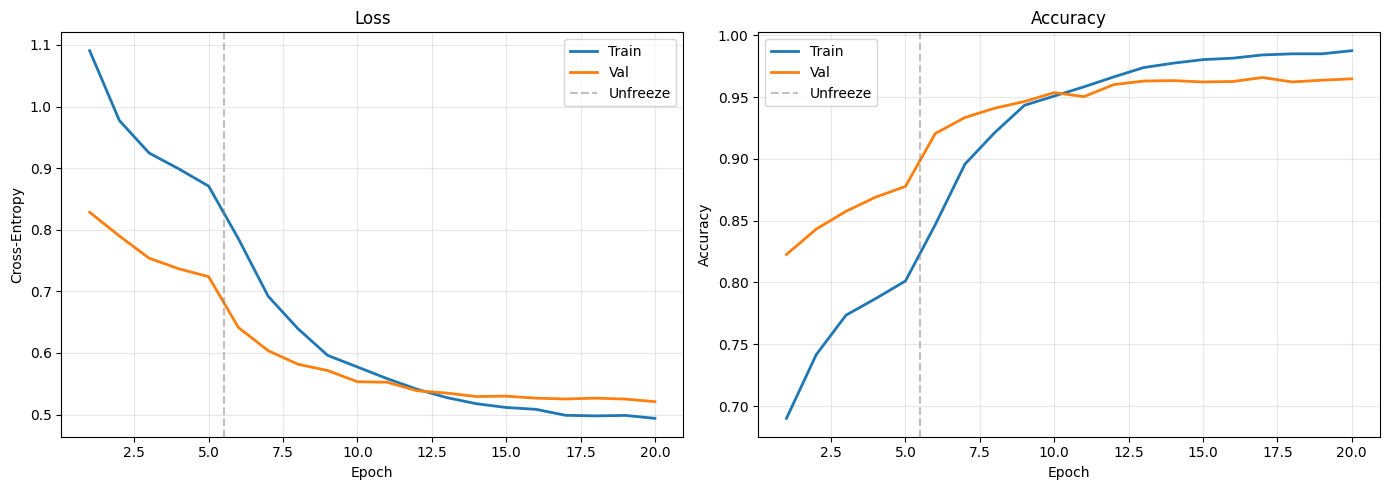

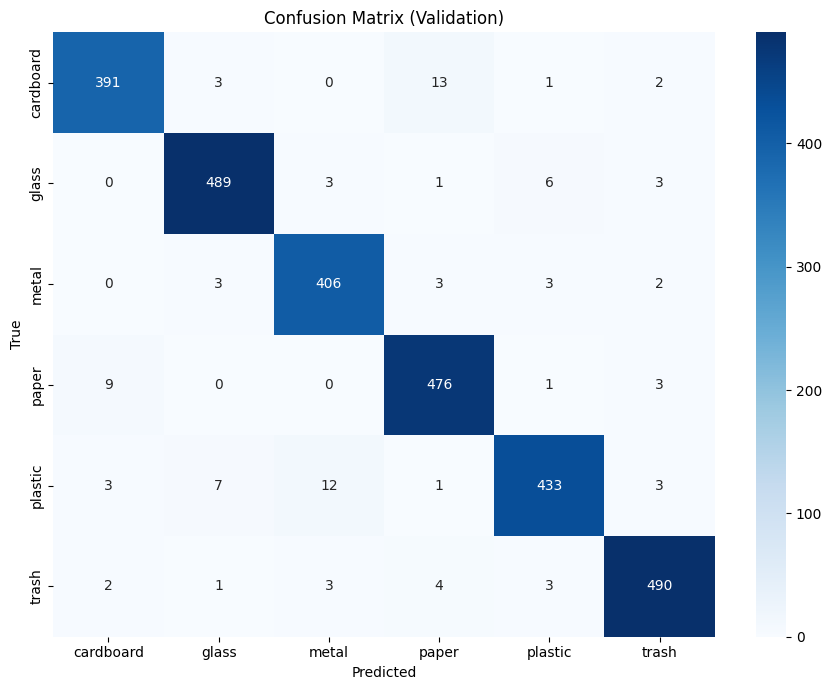


── Per-class report ──
              precision    recall  f1-score   support

   cardboard       0.97      0.95      0.96       410
       glass       0.97      0.97      0.97       502
       metal       0.96      0.97      0.97       417
       paper       0.96      0.97      0.96       489
     plastic       0.97      0.94      0.96       459
       trash       0.97      0.97      0.97       503

    accuracy                           0.97      2780
   macro avg       0.97      0.97      0.97      2780
weighted avg       0.97      0.97      0.97      2780



In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs_x, history["val_loss"],   label="Val",   linewidth=2)
axes[0].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", alpha=0.5, label="Unfreeze")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-Entropy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs_x, history["val_acc"],   label="Val",   linewidth=2)
axes[1].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", alpha=0.5, label="Unfreeze")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

# ── Confusion matrix ─────────────────────────────────────────────────────
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix (Validation)"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

print("\n── Per-class report ──")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

In [7]:
# Export as TorchScript for easy deployment
model.eval()
scripted = torch.jit.script(model)
scripted.save(f"{OUTPUT_DIR}/waste_classifier_scripted.pt")

# Also save class mapping
import json
with open(f"{OUTPUT_DIR}/class_mapping.json", "w") as f:
    json.dump({i: c for i, c in enumerate(CLASSES)}, f, indent=2)

print("Saved:")
print(f"  {OUTPUT_DIR}/best_model.pth          ← raw weights")
print(f"  {OUTPUT_DIR}/waste_classifier_scripted.pt ← TorchScript")
print(f"  {OUTPUT_DIR}/class_mapping.json      ← class index map")

Saved:
  /kaggle/working/best_model.pth          ← raw weights
  /kaggle/working/waste_classifier_scripted.pt ← TorchScript
  /kaggle/working/class_mapping.json      ← class index map
